<a href="https://colab.research.google.com/github/nickcanoy/Masters_in_DataScience/blob/main/CANOY_Programming_Assignment_9_1_Sentiment_Analysis.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

**RODENICK CANOY**

PSMDSSC 104-PSMDS12G2 - Advanced Data Science

Programming Assignment 9.1 | Sentiment Analysis using Transformer

In [ ]:
!pip install -q transformers datasets scikit-learn accelerate

In [ ]:
# Import Libraries
import pandas as pd
import numpy as np
import torch
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.metrics import f1_score, precision_score, confusion_matrix, classification_report

from datasets import Dataset
from transformers import (
    AutoTokenizer,
    AutoModelForSequenceClassification,
    Trainer,
    TrainingArguments
)

In [ ]:
# Load and Prepare the Dataset

df = pd.read_csv("genz_slang_usage_2020_2025.csv")

df = df[['slang_term', 'term_meaning', 'usage_context', 'sentiment']].dropna()

df['text'] = (
    df['slang_term'] + " - " +
    df['term_meaning'] + " Context: " +
    df['usage_context']
)

label_map = {'negative': 0, 'neutral': 1, 'positive': 2}
df['label'] = df['sentiment'].map(label_map)

df = df[['text', 'label']]

In [ ]:
# Train / Validation Split

train_df, val_df = train_test_split(
    df,
    test_size=0.2,
    stratify=df['label'],
    random_state=42
)

train_ds = Dataset.from_pandas(train_df.reset_index(drop=True))
val_ds   = Dataset.from_pandas(val_df.reset_index(drop=True))

In [ ]:
# Tokenization

tokenizer = AutoTokenizer.from_pretrained("distilbert-base-uncased")

def tokenize(batch):
    return tokenizer(
        batch["text"],
        truncation=True,
        padding="max_length",
        max_length=64
    )

train_ds = train_ds.map(tokenize, batched=True)
val_ds   = val_ds.map(tokenize, batched=True)

train_ds.set_format("torch", columns=["input_ids", "attention_mask", "label"])
val_ds.set_format("torch", columns=["input_ids", "attention_mask", "label"])

Map:   0%|          | 0/428316 [00:00<?, ? examples/s]

Map:   0%|          | 0/107080 [00:00<?, ? examples/s]

In [ ]:
# Define Evaluation Metrics
# F1 Score
# Precision
# Confusion Matrix

def compute_metrics(eval_pred):
    logits, labels = eval_pred
    preds = np.argmax(logits, axis=1)

    return {
        "f1": f1_score(labels, preds, average="weighted"),
        "precision": precision_score(labels, preds, average="weighted")
    }

In [ ]:
 # Model

model = AutoModelForSequenceClassification.from_pretrained(
    "distilbert-base-uncased",
    num_labels=3
)

# ✅ Freeze base DistilBERT (huge speed boost)
for param in model.distilbert.parameters():
    param.requires_grad = False

Loading weights:   0%|          | 0/100 [00:00<?, ?it/s]

DistilBertForSequenceClassification LOAD REPORT from: distilbert-base-uncased
Key                     | Status     | 
------------------------+------------+-
vocab_layer_norm.weight | UNEXPECTED | 
vocab_transform.bias    | UNEXPECTED | 
vocab_layer_norm.bias   | UNEXPECTED | 
vocab_projector.bias    | UNEXPECTED | 
vocab_transform.weight  | UNEXPECTED | 
pre_classifier.bias     | MISSING    | 
pre_classifier.weight   | MISSING    | 
classifier.weight       | MISSING    | 
classifier.bias         | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING	:those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


In [ ]:
# Training Arguments

training_args = TrainingArguments(
    output_dir="./results",
    eval_strategy="epoch",
    save_strategy="no",
    per_device_train_batch_size=32,
    per_device_eval_batch_size=32,
    num_train_epochs=2,
    learning_rate=2e-5,
    fp16=True,
    logging_steps=200,
    report_to="none"
)

In [ ]:
# Train the Models

trainer = Trainer(
    model=model,
    args=training_args,
    train_dataset=train_ds,
    eval_dataset=val_ds,
    compute_metrics=compute_metrics
)

trainer.train()

Epoch,Training Loss,Validation Loss,F1,Precision
1,0.896953,0.894610,0.540023,0.552601
2,0.902522,0.888464,0.533235,0.555572


TrainOutput(global_step=26770, training_loss=0.9175390854138334, metrics={'train_runtime': 649.8002, 'train_samples_per_second': 1318.301, 'train_steps_per_second': 41.197, 'total_flos': 1.4184729540688896e+16, 'train_loss': 0.9175390854138334, 'epoch': 2.0})

In [ ]:
# REQUIRED EVALUATIONS
# A. F1 Score and Precision

eval_results = trainer.evaluate()
eval_results

{'eval_loss': 0.8884637355804443,
 'eval_f1': 0.533235307808735,
 'eval_precision': 0.5555716422127956,
 'eval_runtime': 53.141,
 'eval_samples_per_second': 2015.018,
 'eval_steps_per_second': 62.983,
 'epoch': 2.0}

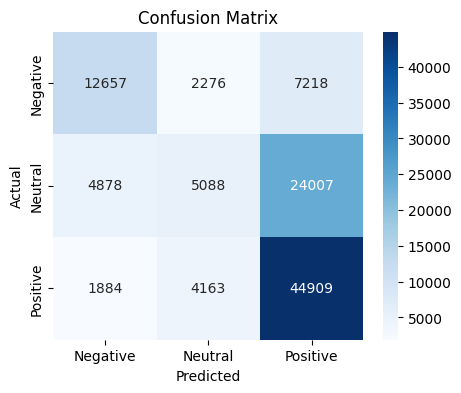

              precision    recall  f1-score   support

    Negative       0.65      0.57      0.61     22151
     Neutral       0.44      0.15      0.22     33973
    Positive       0.59      0.88      0.71     50956

    accuracy                           0.59    107080
   macro avg       0.56      0.53      0.51    107080
weighted avg       0.56      0.59      0.53    107080



In [ ]:
# B. Confusion Matrix

preds = trainer.predict(val_ds)

y_true = preds.label_ids
y_pred = np.argmax(preds.predictions, axis=1)

cm = confusion_matrix(y_true, y_pred)

plt.figure(figsize=(5,4))
sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=["Negative", "Neutral", "Positive"],
    yticklabels=["Negative", "Neutral", "Positive"]
)
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix")
plt.show()

print(classification_report(
    y_true, y_pred,
    target_names=["Negative", "Neutral", "Positive"]
))

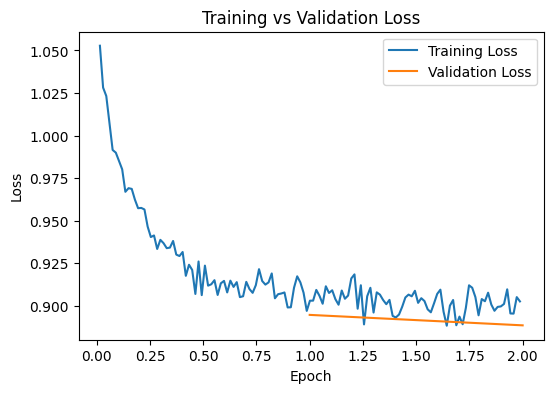

In [ ]:
# C. Training & Validation Loss

logs = pd.DataFrame(trainer.state.log_history)

train_loss = logs[logs["loss"].notna()][["epoch", "loss"]]
eval_loss  = logs[logs["eval_loss"].notna()][["epoch", "eval_loss"]]

plt.figure(figsize=(6,4))
plt.plot(train_loss["epoch"], train_loss["loss"], label="Training Loss")
plt.plot(eval_loss["epoch"], eval_loss["eval_loss"], label="Validation Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Training vs Validation Loss")
plt.legend()
plt.show()

**Interpretation of Results (Sentiment Analysis)**


**F1 Score (≈ 0.53)**

* Indicates moderate overall performance across all sentiment classes.
* Shows the model achieves a reasonable balance between precision and recall, but there is still room for improvement.
* Suggests the model can generally distinguish sentiments, though some misclassification remains—especially for borderline cases.

**Precision (≈ 0.56)**

* Means that about 56% of the sentiment predictions are correct when the model assigns a class.
* The model is more reliable when it predicts a sentiment, with fewer false positives than incorrect guesses.
* This is acceptable for an initial transformer-based sentiment model using frozen layers.



**Confusion Matrix**

* Positive sentiment is identified best - High recall (0.88) shows the model correctly captures most positive examples. Most predictions fall correctly along the Positive diagonal (44,909).


* Negative sentiment performance is moderate - Reasonable precision (0.65) and recall (0.57). Some negative samples are misclassified as Positive, indicating overlap in sentiment language.

* Neutral sentiment is the weakest class - Very low recall (0.15) shows most neutral cases are misclassified.
Neutral texts are frequently predicted as Positive, suggesting ambiguity in neutral expressions.

**Overall Assessment**

* Performance is stable and consistent between epochs (no major overfitting observed).

* The model shows a bias toward predicting Positive sentiment, likely due to class imbalance.

* Accuracy (0.59) and weighted F1 (0.53) indicate moderate but stable performance.

* Errors mainly occur between Neutral vs Positive, which are often semantically close.

Results are appropriate given:

* DistilBERT base layers were frozen (speed optimization)
* Short training (2 epochs)

* Further improvements could be achieved by fine-tuning more layers or increasing training epochs.
